# 스프린트 미션 14 — SNS 텍스트 감정 분석

**제출 파일명:** `미션14_팀명_성함.ipynb`  
**구성:** 데이터 감사 → 텍스트 전처리 → 품사 기반 워드클라우드 → Logistic Regression 기준선 → 모델 개선 → 오분류 분석 → 이진 분류

이 노트북은 Google Colab에서 위에서 아래로 실행할 수 있습니다. `text_emotions_training.csv`와 `text_emotions_test.csv`를 업로드하면 됩니다.

## 분석 원칙

1. 테스트셋은 모델 선택이 끝난 뒤 한 번만 평가합니다.
2. 클래스 불균형을 고려해 Macro F1을 주 지표로 사용합니다.
3. 워드클라우드용 전처리와 분류용 전처리를 분리합니다.
4. 다중 분류뿐 아니라 surprise를 제외한 긍정·부정 이진 분류도 수행합니다.

In [1]:
import importlib.util
required = ['pandas','numpy','sklearn','matplotlib','seaborn','nltk','wordcloud','joblib']
if any(importlib.util.find_spec(m) is None for m in required):
    get_ipython().run_line_magic('pip', '-q install pandas numpy scipy scikit-learn matplotlib seaborn nltk wordcloud joblib')

In [2]:
from pathlib import Path
from collections import Counter
import os, re, warnings, json
warnings.filterwarnings('ignore')
os.environ.setdefault('OMP_NUM_THREADS','4')

import joblib
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.base import clone
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.svm import LinearSVC
from wordcloud import WordCloud

RANDOM_STATE = 42
LABELS = {0:'sadness',1:'joy',2:'love',3:'anger',4:'fear',5:'surprise'}
LABELS_KO = {0:'슬픔',1:'기쁨',2:'사랑',3:'화남',4:'두려움',5:'놀람'}
LABEL_ORDER = list(range(6))
COLORS = {0:'#4E79A7',1:'#F2B134',2:'#E56B9F',3:'#E15759',4:'#7A67B3',5:'#2A9D8F'}
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['axes.unicode_minus'] = False
for font in ['Malgun Gothic','NanumGothic','DejaVu Sans']:
    try:
        plt.rcParams['font.family'] = font
        break
    except Exception:
        pass

## 1. 데이터 로드

In [3]:
def load_csv(filename):
    candidates = [Path('/content')/filename, Path(filename), Path('work/mission14')/filename, Path('../work/mission14')/filename]
    for p in candidates:
        if p.exists():
            print('Loaded:', p.resolve())
            return pd.read_csv(p)
    try:
        from google.colab import files
        print(f'{filename} 파일을 업로드하세요.')
        uploaded = files.upload()
        return pd.read_csv(next(iter(uploaded)))
    except Exception as e:
        raise FileNotFoundError(filename) from e

train = load_csv('text_emotions_training.csv')
test = load_csv('text_emotions_test.csv')
print('train:', train.shape, 'test:', test.shape)
display(train.head())

Loaded: C:\Users\lucy5\Documents\Codex\2026-09-14\13-1-eda-2-k-means\work\mission14\text_emotions_training.csv
Loaded: C:\Users\lucy5\Documents\Codex\2026-09-14\13-1-eda-2-k-means\work\mission14\text_emotions_test.csv
train: (17948, 2) test: (2000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


## 2. 데이터 무결성 감사

In [4]:
def normalize_for_audit(text):
    return re.sub(r'\s+', ' ', str(text).strip().lower())

train_norm = train.text.map(normalize_for_audit)
test_norm = test.text.map(normalize_for_audit)
audit = pd.DataFrame({
    'train':[len(train),train.isna().sum().sum(),train_norm.duplicated().sum(),np.nan],
    'test':[len(test),test.isna().sum().sum(),test_norm.duplicated().sum(),len(set(train_norm)&set(test_norm))],
}, index=['rows','missing','duplicate_text','train_test_overlap'])
display(audit)

,train,test
rows,17948.0,2000
missing,0.0,0
duplicate_text,0.0,0
train_test_overlap,NaN,0


In [5]:
label_dist = pd.DataFrame({
    'train_n': train.label.value_counts().reindex(LABEL_ORDER),
    'train_share': train.label.value_counts(normalize=True).reindex(LABEL_ORDER),
    'test_n': test.label.value_counts().reindex(LABEL_ORDER),
    'test_share': test.label.value_counts(normalize=True).reindex(LABEL_ORDER),
})
label_dist.index = [LABELS[i] for i in LABEL_ORDER]
display(label_dist)

,train_n,train_share,test_n,test_share
sadness,5213,0.290450,581,0.2905
joy,6048,0.336973,695,0.3475
love,1469,0.081848,159,0.0795
anger,2429,0.135335,275,0.1375
fear,2142,0.119345,224,0.1120
surprise,647,0.036049,66,0.0330


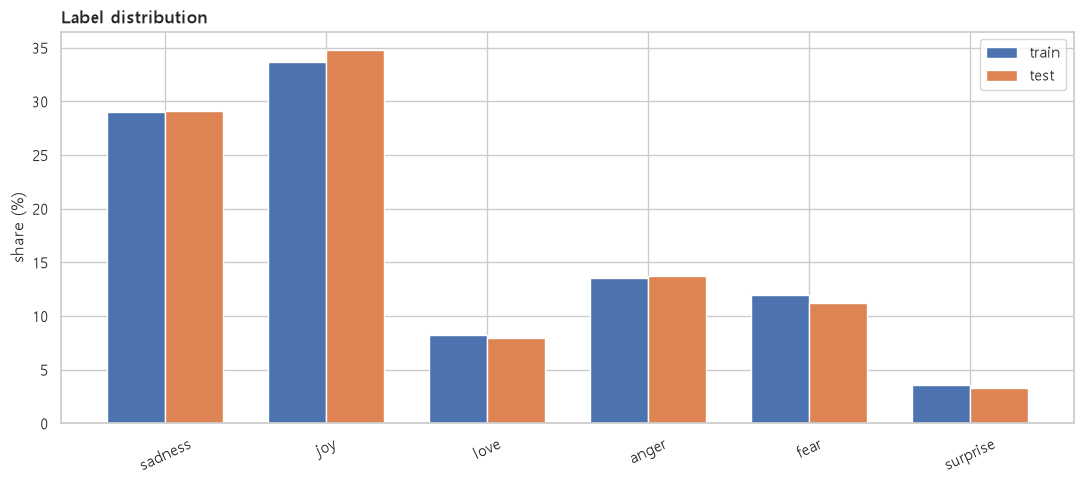

In [6]:
x=np.arange(6); w=.36
plt.figure(figsize=(11,5))
plt.bar(x-w/2,label_dist.train_share*100,w,label='train')
plt.bar(x+w/2,label_dist.test_share*100,w,label='test')
plt.xticks(x,label_dist.index,rotation=25); plt.ylabel('share (%)'); plt.legend()
plt.title('Label distribution',loc='left',fontweight='bold'); plt.tight_layout(); plt.show()

## 3. 텍스트 길이와 표본 확인

In [7]:
for frame in [train,test]:
    frame['word_count']=frame.text.astype(str).str.split().str.len()
    frame['char_count']=frame.text.astype(str).str.len()
display(train[['word_count','char_count']].describe(percentiles=[.01,.1,.5,.9,.99]))
display(test[['word_count','char_count']].describe(percentiles=[.01,.1,.5,.9,.99]))

,word_count,char_count
count,17948.000000,17948.000000
mean,19.139403,96.713561
std,10.972552,55.810534
min,2.000000,7.000000
1%,4.000000,20.000000
10%,7.000000,34.000000
50%,17.000000,86.000000
90%,35.000000,175.000000
99%,52.000000,263.000000
max,66.000000,300.000000


,word_count,char_count
count,2000.000000,2000.000000
mean,19.154000,96.586500
std,11.012353,55.715991
min,3.000000,14.000000
1%,4.000000,21.000000
10%,7.000000,34.000000
50%,17.000000,86.000000
90%,35.000000,175.100000
99%,51.010000,256.010000
max,61.000000,296.000000


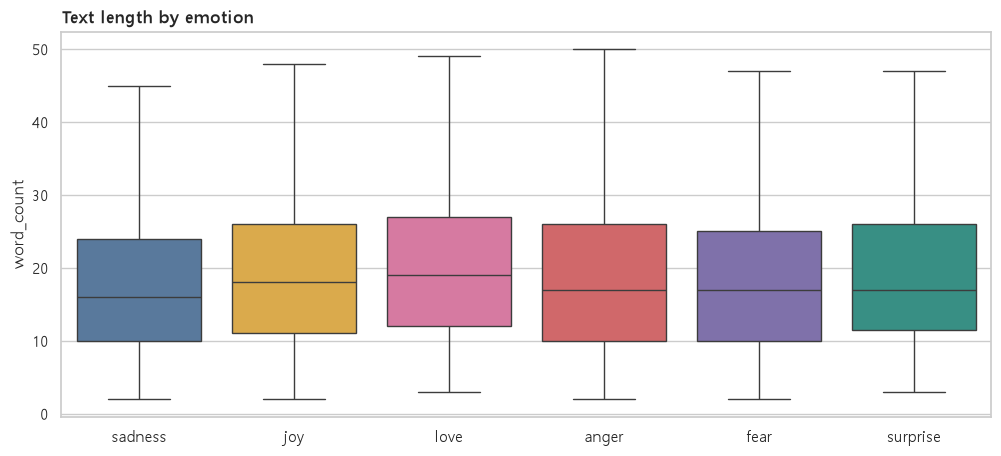

In [8]:
plot_df=train.assign(emotion=train.label.map(LABELS))
plt.figure(figsize=(12,5))
sns.boxplot(data=plot_df,x='emotion',y='word_count',order=[LABELS[i] for i in LABEL_ORDER],
            palette=[COLORS[i] for i in LABEL_ORDER],showfliers=False)
plt.xlabel(''); plt.title('Text length by emotion',loc='left',fontweight='bold'); plt.show()

In [9]:
samples=(train.groupby('label',group_keys=False).sample(2,random_state=RANDOM_STATE)
         .assign(emotion=lambda d:d.label.map(LABELS)))[['emotion','text']]
display(samples)

,emotion,text
6578,sadness,i feel it is unfortunate that in the end my ye...
3092,sadness,i think this will help somebody out there that...
5416,joy,i bring these to mind and feel the joyful laug...
17518,joy,i feel like someone needs to invest money in i...
12495,love,i visit cantina i leave feeling that the food ...
1397,love,i feel like telling these horny devils to find...
2205,anger,i end up getting unwanted attention from boys ...
14529,anger,im feeling less hateful of fandom
6294,fear,ill admit to feeling a little paranoid and won...
4309,fear,i began to feel less anxious


## 4. 분류용 최소 전처리

In [10]:
def clean_text(text):
    text=str(text).lower().replace('’',"'")
    text=re.sub(r'https?://\S+|www\.\S+',' URL ',text)
    text=re.sub(r'@\w+',' USER ',text)
    text=re.sub(r'#(\w+)',r'  ',text)
    text=re.sub(r"[^a-z'\s]",' ',text)
    return re.sub(r'\s+',' ',text).strip()
train['clean_text']=train.text.map(clean_text)
test['clean_text']=test.text.map(clean_text)
display(pd.DataFrame({'raw':train.text.head(8),'clean':train.clean_text.head(8)}))

,raw,clean
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive been feeling a little burdened lately wasn...
6,ive been taking or milligrams or times recomme...,ive been taking or milligrams or times recomme...
7,i feel as confused about life as a teenager or...,i feel as confused about life as a teenager or...


분류 입력에서는 불용어와 품사를 제거하지 않습니다. `not`, 대명사, 조동사도 감정 문맥을 전달할 수 있고 문자 n-gram이 비표준 축약과 철자 변형을 보완합니다.

## 5. 워드클라우드용 품사·표제어 전처리

In [11]:
nltk_dir = Path('/content/nltk_data') if Path('/content').exists() else Path('work/mission14/nltk_data')
nltk_dir.mkdir(parents=True,exist_ok=True)
nltk.data.path.insert(0,str(nltk_dir))
for pkg in ['averaged_perceptron_tagger_eng','wordnet','omw-1.4','stopwords']:
    nltk.download(pkg,download_dir=str(nltk_dir),quiet=True)

GENERIC={'feel','feeling','felt','feels','im','ive','id','ill','dont','didnt','really','like','know',
         'think','want','make','get','got','time','day','thing','things','people','person','little','bit',
         'much','still','even','one','also','would','could','say','said','going','way','something'}
base_stop=set(ENGLISH_STOP_WORDS)|set(stopwords.words('english'))|GENERIC
lemma=WordNetLemmatizer()

def wn_pos(tag):
    if tag.startswith('N'): return 'n'
    if tag.startswith('V'): return 'v'
    if tag.startswith('J'): return 'a'
    if tag.startswith('R'): return 'r'
    return None

In [12]:
token_lists=[re.findall(r'[a-z]+',clean_text(t)) for t in train.text]
tagged_sents=nltk.pos_tag_sents(token_lists)
content_docs=[]
for sent in tagged_sents:
    kept=[]
    for word,tag in sent:
        pos=wn_pos(tag)
        if pos and len(word)>=3 and word not in base_stop:
            token=lemma.lemmatize(word,pos=pos)
            if token not in base_stop and len(token)>=3:
                kept.append(token)
    content_docs.append(kept)
top_sets=[]
for label in LABEL_ORDER:
    counter=Counter(w for i,doc in enumerate(content_docs) if train.label.iloc[i]==label for w in doc)
    top_sets.append({w for w,_ in counter.most_common(80)})
dynamic_common=set.intersection(*top_sets)
content_docs=[[w for w in doc if w not in dynamic_common] for doc in content_docs]
train['content_text']=[' '.join(doc) for doc in content_docs]
print('Dynamically removed common terms:', sorted(dynamic_common))
display(train[['text','content_text']].head(10))

Dynamically removed common terms: ['come', 'friend', 'good', 'help', 'leave', 'life', 'look', 'lot', 'love', 'need', 'quite', 'right', 'start', 'talk', 'tell', 'today', 'try', 'use', 'work', 'write', 'year']


,text,content_text
0,i didnt feel humiliated,humiliate
1,i can go from feeling so hopeless to so damned...,hopeless damned hopeful care awake
2,im grabbing a minute to post i feel greedy wrong,grab minute post greedy wrong
3,i am ever feeling nostalgic about the fireplac...,nostalgic fireplace property
4,i am feeling grouchy,grouchy
5,ive been feeling a little burdened lately wasn...,burdened lately wasnt sure
6,ive been taking or milligrams or times recomme...,milligram recommended fall asleep faster funny
7,i feel as confused about life as a teenager or...,confuse teenager jade old man
8,i have been with petronas for years i feel tha...,petronas petronas perform huge profit
9,i feel romantic too,romantic


## 6. 감정 특이도 가중치

In [13]:
vec_wc=CountVectorizer(min_df=3,token_pattern=r'(?u)\b[a-z]{3,}\b')
X_wc=vec_wc.fit_transform(train.content_text)
wc_terms=vec_wc.get_feature_names_out()
refined_weights={}; keyword_rows=[]
for label in LABEL_ORDER:
    target=train.label.values==label
    class_counts=np.asarray(X_wc[target].sum(axis=0)).ravel()
    rest_counts=np.asarray(X_wc[~target].sum(axis=0)).ravel()
    chi_score,_=chi2(X_wc,target.astype(int))
    V=len(wc_terms)
    lift=np.log(((class_counts+1)/(class_counts.sum()+V))/((rest_counts+1)/(rest_counts.sum()+V)))
    score=chi_score*np.maximum(lift,0)
    idx=np.argsort(score)[-120:]
    refined_weights[label]={wc_terms[i]:float(score[i]) for i in idx if score[i]>0}
    for rank,i in enumerate(idx[::-1][:30],1):
        keyword_rows.append({'label':label,'emotion':LABELS[label],'rank':rank,'term':wc_terms[i],
                             'score':score[i],'class_count':class_counts[i],'other_count':rest_counts[i]})
keywords=pd.DataFrame(keyword_rows)
display(keywords.groupby('emotion').head(12))

,label,emotion,rank,term,score,class_count,other_count
0,0,sadness,1,gloomy,786.735374,64,0
1,0,sadness,2,inadequate,713.734882,59,0
2,0,sadness,3,unimportant,699.256280,58,0
3,0,sadness,4,melancholy,698.382214,67,1
4,0,sadness,5,punish,665.185336,71,2
...,...,...,...,...,...,...,...
157,5,surprise,8,shock,2265.325810,37,15
158,5,surprise,9,surprise,2062.106249,45,28
159,5,surprise,10,stun,1840.759522,16,1
160,5,surprise,11,shocked,1610.074552,12,0


## 7. 감정별 워드클라우드

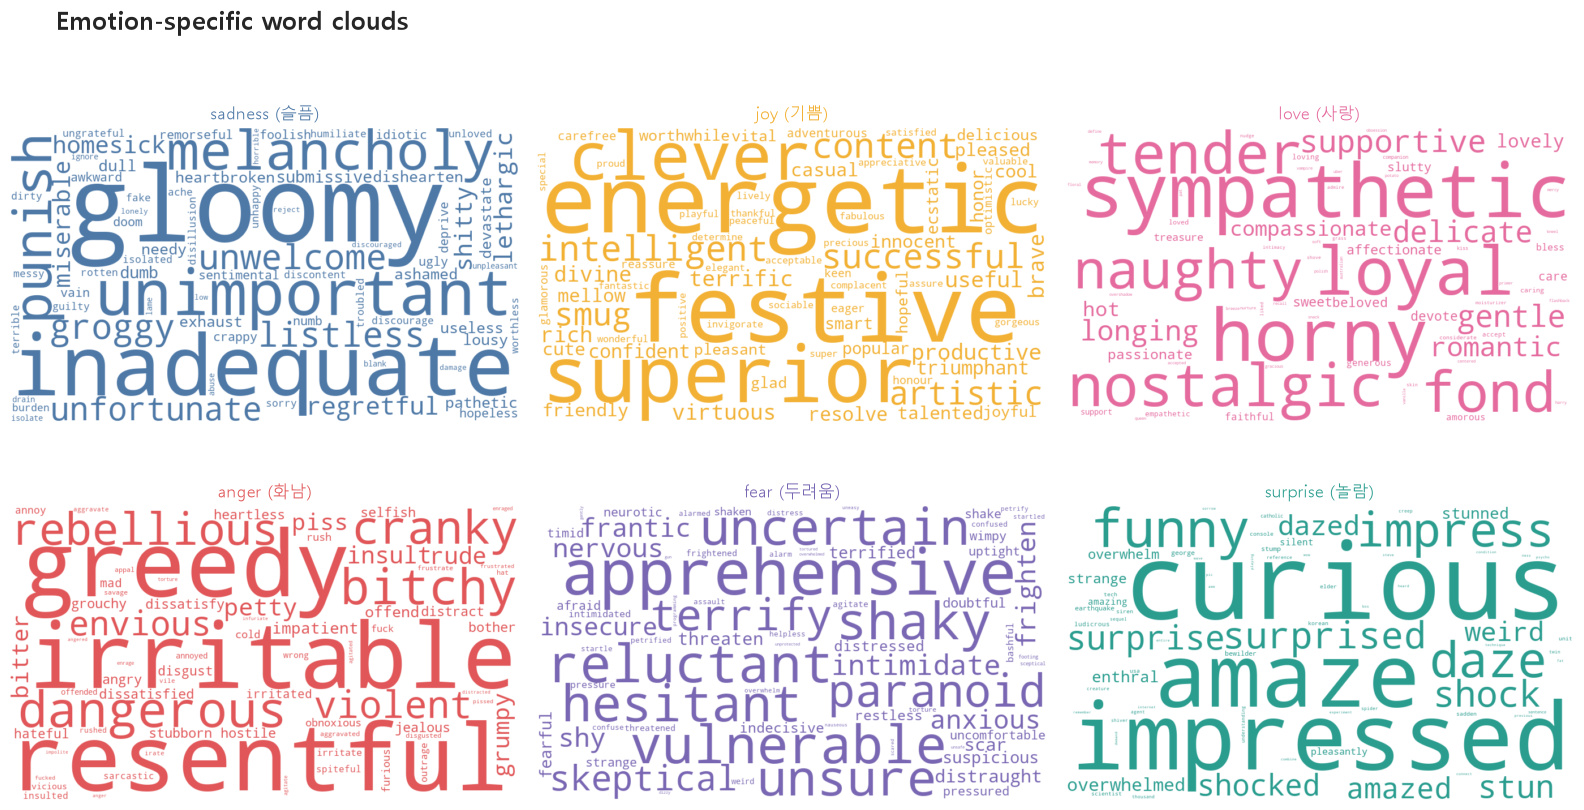

In [14]:
fig,axes=plt.subplots(2,3,figsize=(16,9))
for label,ax in zip(LABEL_ORDER,axes.ravel()):
    wc=WordCloud(width=900,height=520,background_color='white',max_words=70,random_state=RANDOM_STATE,
                 collocations=False,color_func=lambda *args,_c=COLORS[label],**kwargs:_c)
    wc.generate_from_frequencies(refined_weights[label])
    ax.imshow(wc,interpolation='bilinear'); ax.axis('off')
    ax.set_title(f'{LABELS[label]} ({LABELS_KO[label]})',color=COLORS[label])
plt.suptitle('Emotion-specific word clouds',x=.04,ha='left',fontweight='bold',fontsize=18)
plt.tight_layout(); plt.show()

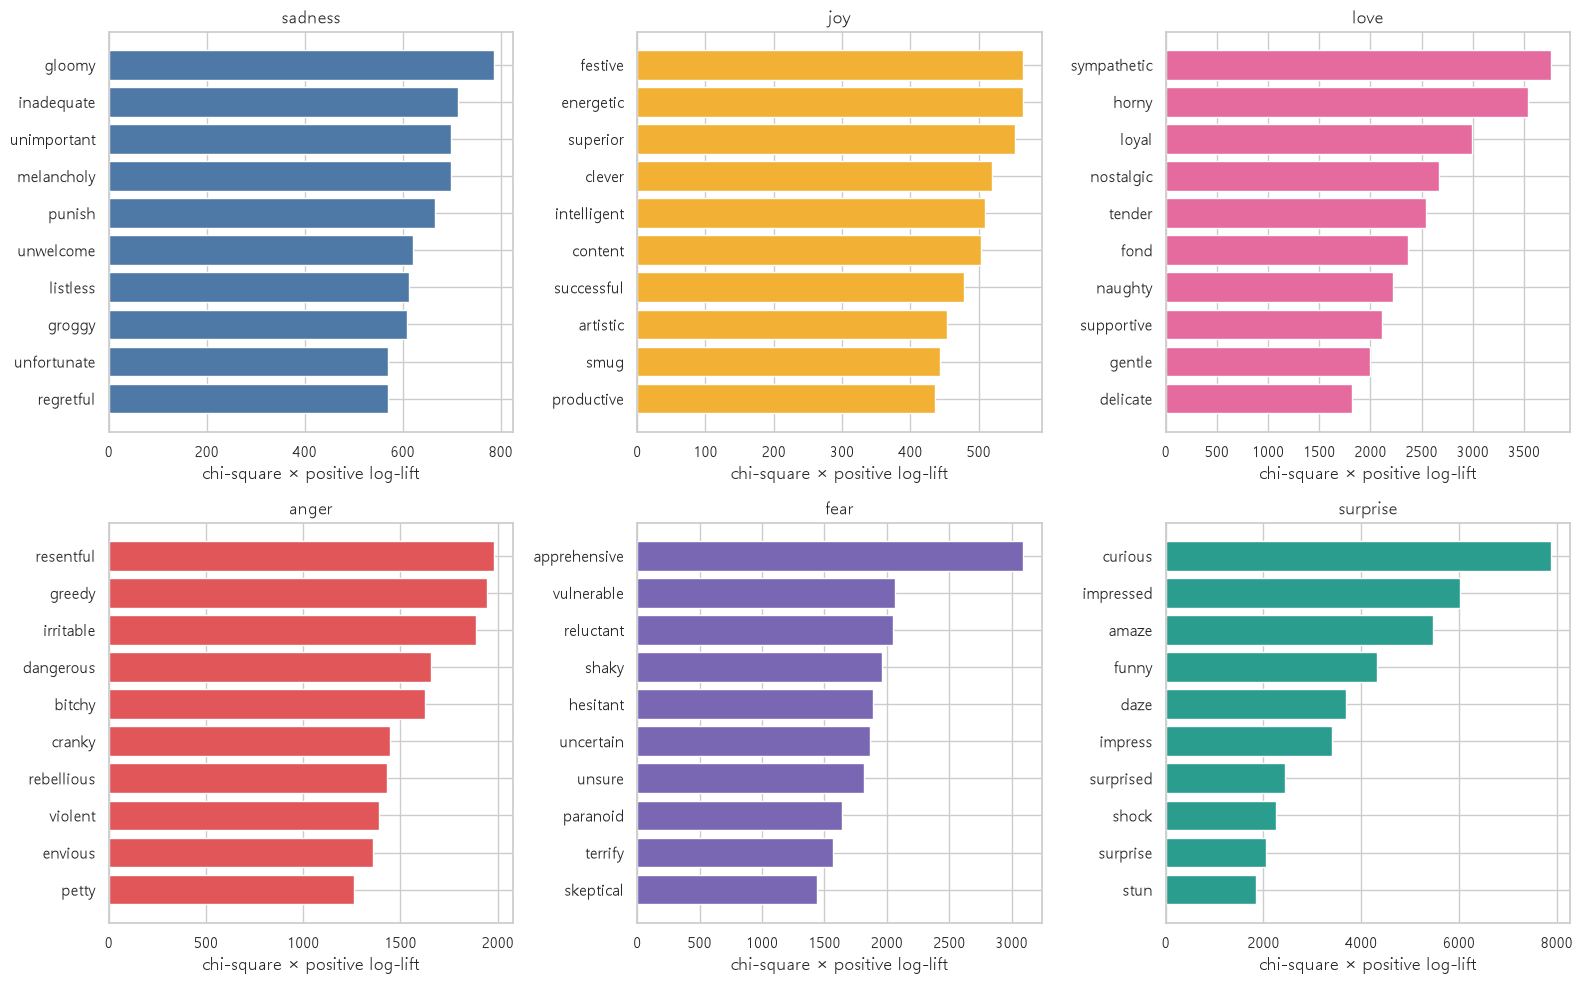

In [15]:
fig,axes=plt.subplots(2,3,figsize=(16,10))
for label,ax in zip(LABEL_ORDER,axes.ravel()):
    t=keywords.query('label==@label').head(10).sort_values('score')
    ax.barh(t.term,t.score,color=COLORS[label]); ax.set_title(LABELS[label])
    ax.set_xlabel('chi-square × positive log-lift')
plt.tight_layout(); plt.show()

## 8. 평가 설계

모델 선택은 학습셋 내부 Stratified 3-fold 교차검증으로 수행합니다. 클래스 불균형 때문에 Macro F1을 우선하며 테스트셋은 최종 모델이 정해진 뒤 한 번만 사용합니다.

In [16]:
cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=RANDOM_STATE)
def evaluate_cv(name,model,X,y):
    s=cross_validate(model,X,y,cv=cv,scoring={'accuracy':'accuracy','macro_f1':'f1_macro'},n_jobs=1)
    return {'model':name,'cv_accuracy':s['test_accuracy'].mean(),
            'cv_macro_f1':s['test_macro_f1'].mean(),'macro_f1_std':s['test_macro_f1'].std()}

## 9. 기준 모델 — Logistic Regression

In [17]:
baseline=Pipeline([
    ('vec',CountVectorizer(min_df=2,ngram_range=(1,1))),
    ('clf',LogisticRegression(max_iter=1200,C=1,class_weight='balanced'))])
baseline_result=evaluate_cv('Baseline Count unigram + Logistic Regression',baseline,train.clean_text,train.label)
baseline_result

{'model': 'Baseline Count unigram + Logistic Regression',
 'cv_accuracy': np.float64(0.8868398517371343),
 'cv_macro_f1': np.float64(0.8550153090976337),
 'macro_f1_std': np.float64(0.002071001509199306)}

## 10. 개선 후보 — TF-IDF, Linear SVM, 문자 n-gram, ComplementNB

In [18]:
def make_hybrid_model():
    return Pipeline([
        ('features',FeatureUnion([
            ('word',TfidfVectorizer(ngram_range=(1,2),min_df=2,max_df=.99,sublinear_tf=True,max_features=180000)),
            ('char',TfidfVectorizer(analyzer='char_wb',ngram_range=(3,5),min_df=2,sublinear_tf=True,max_features=180000)),
        ],transformer_weights={'word':1.0,'char':.5})),
        ('clf',LinearSVC(C=1.0,class_weight='balanced'))])

candidates={
    'TF-IDF word 1–2gram + Logistic Regression':Pipeline([
        ('vec',TfidfVectorizer(ngram_range=(1,2),min_df=2,max_df=.99,sublinear_tf=True,max_features=180000)),
        ('clf',LogisticRegression(max_iter=1200,C=4,class_weight='balanced'))]),
    'TF-IDF word 1–2gram + Linear SVM':Pipeline([
        ('vec',TfidfVectorizer(ngram_range=(1,2),min_df=2,max_df=.99,sublinear_tf=True,max_features=180000)),
        ('clf',LinearSVC(C=1.5,class_weight='balanced'))]),
    'TF-IDF char 3–5gram + Linear SVM':Pipeline([
        ('vec',TfidfVectorizer(analyzer='char_wb',ngram_range=(3,5),min_df=2,sublinear_tf=True,max_features=180000)),
        ('clf',LinearSVC(C=2,class_weight='balanced'))]),
    'TF-IDF word 1–2gram + ComplementNB':Pipeline([
        ('vec',TfidfVectorizer(ngram_range=(1,2),min_df=2,max_df=.99,sublinear_tf=True,max_features=180000)),
        ('clf',ComplementNB(alpha=.5))]),
    'Hybrid word+char TF-IDF + Linear SVM':make_hybrid_model(),
}

In [19]:
cv_rows=[baseline_result]
for name,model in candidates.items():
    cv_rows.append(evaluate_cv(name,model,train.clean_text,train.label))
pos_model=Pipeline([
    ('vec',TfidfVectorizer(ngram_range=(1,2),min_df=2,sublinear_tf=True,max_features=180000)),
    ('clf',LinearSVC(C=1.5,class_weight='balanced'))])
cv_rows.append(evaluate_cv('POS content words only + Linear SVM',pos_model,train.content_text,train.label))
cv_results=pd.DataFrame(cv_rows).sort_values('cv_macro_f1',ascending=False)
display(cv_results)

,model,cv_accuracy,cv_macro_f1,macro_f1_std
5,Hybrid word+char TF-IDF + Linear SVM,0.894807,0.862659,0.003243
2,TF-IDF word 1–2gram + Linear SVM,0.889347,0.855644,0.002092
0,Baseline Count unigram + Logistic Regression,0.886840,0.855015,0.002071
1,TF-IDF word 1–2gram + Logistic Regression,0.876867,0.845756,0.006037
3,TF-IDF char 3–5gram + Linear SVM,0.873579,0.841472,0.004314
4,TF-IDF word 1–2gram + ComplementNB,0.871295,0.833950,0.001806
6,POS content words only + Linear SVM,0.857143,0.822008,0.006221


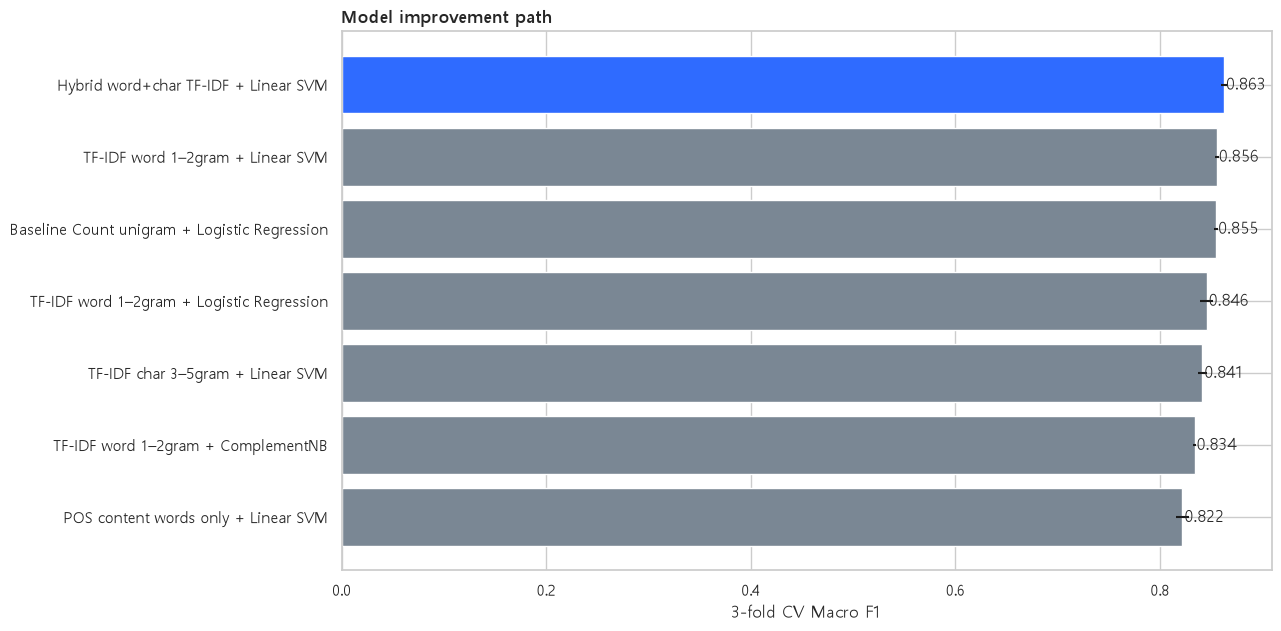

In [20]:
t=cv_results.sort_values('cv_macro_f1')
plt.figure(figsize=(12,7))
colors=['#2F6BFF' if 'Hybrid' in x else '#7A8794' for x in t.model]
plt.barh(t.model,t.cv_macro_f1,xerr=t.macro_f1_std,color=colors)
plt.xlabel('3-fold CV Macro F1'); plt.title('Model improvement path',loc='left',fontweight='bold')
for y,v in enumerate(t.cv_macro_f1): plt.text(v+.002,y,f'{v:.3f}',va='center')
plt.show()

Word TF-IDF는 의미 단위를, character TF-IDF는 축약·철자 변형을 포착합니다. 품사 제한은 워드클라우드 해석에는 도움이 되지만 분류 문맥을 줄이므로 최종 모델 입력에는 사용하지 않습니다.

## 11. 최종 다중 분류 모델

In [21]:
final_model=make_hybrid_model()
final_model.fit(train.clean_text,train.label)
pred=final_model.predict(test.clean_text)
decision=final_model.decision_function(test.clean_text)
multi_metrics={
    'accuracy':accuracy_score(test.label,pred),
    'macro_f1':f1_score(test.label,pred,average='macro'),
    'weighted_f1':f1_score(test.label,pred,average='weighted')}
multi_metrics

{'accuracy': 0.897,
 'macro_f1': 0.8555701990085227,
 'weighted_f1': 0.8979709538388825}

In [22]:
report=pd.DataFrame(classification_report(test.label,pred,labels=LABEL_ORDER,
                    target_names=[LABELS[i] for i in LABEL_ORDER],output_dict=True,zero_division=0)).T
display(report)

,precision,recall,f1-score,support
sadness,0.950355,0.922547,0.936245,581.000
joy,0.927431,0.919424,0.923410,695.000
love,0.751412,0.836478,0.791667,159.000
anger,0.866197,0.894545,0.880143,275.000
fear,0.890995,0.839286,0.864368,224.000
surprise,0.693333,0.787879,0.737589,66.000
accuracy,0.897000,0.897000,0.897000,0.897
macro avg,0.846621,0.866693,0.855570,2000.000
weighted avg,0.899871,0.897000,0.897971,2000.000


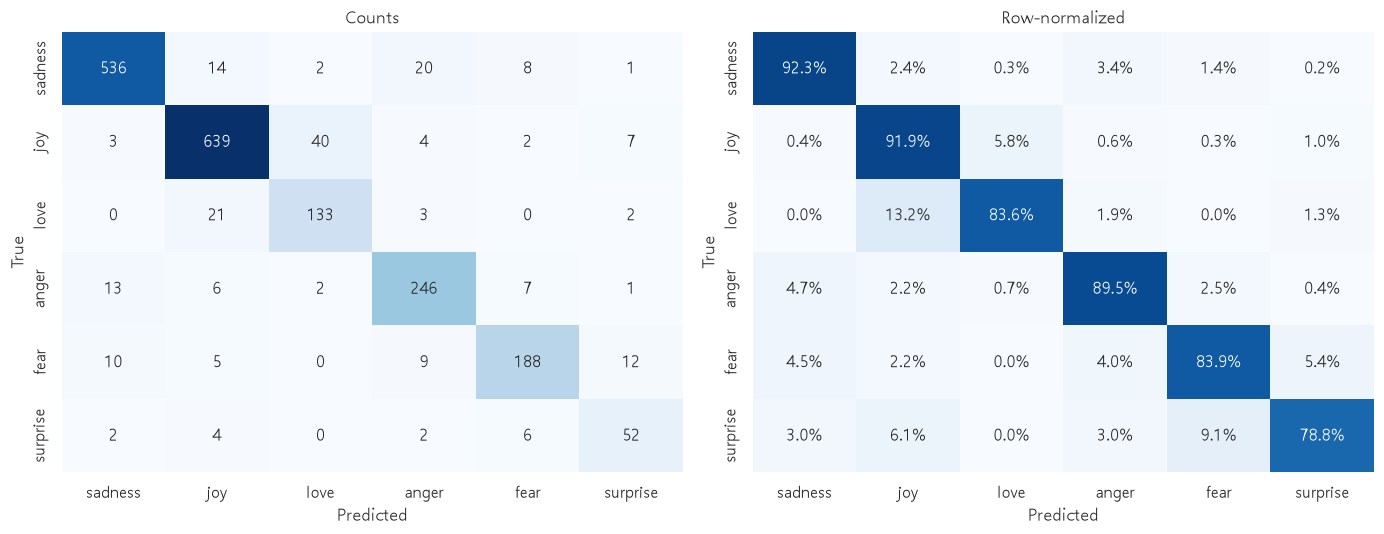

In [23]:
cm=confusion_matrix(test.label,pred,labels=LABEL_ORDER)
cm_norm=confusion_matrix(test.label,pred,labels=LABEL_ORDER,normalize='true')
fig,axes=plt.subplots(1,2,figsize=(14,5.5))
names=[LABELS[i] for i in LABEL_ORDER]
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=names,yticklabels=names,cbar=False,ax=axes[0])
sns.heatmap(cm_norm,annot=True,fmt='.1%',cmap='Blues',vmin=0,vmax=1,xticklabels=names,yticklabels=names,cbar=False,ax=axes[1])
axes[0].set_title('Counts'); axes[1].set_title('Row-normalized')
for ax in axes: ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

## 12. 모델이 사용하는 단어 n-gram

In [24]:
feature_names=final_model.named_steps['features'].get_feature_names_out()
word_mask=np.array([x.startswith('word__') for x in feature_names])
word_names=np.array([x.replace('word__','',1) for x in feature_names[word_mask]])
coef=final_model.named_steps['clf'].coef_[:,word_mask]
coef_rows=[]
for label in LABEL_ORDER:
    idx=np.argsort(coef[label])[-15:][::-1]
    for rank,i in enumerate(idx,1):
        coef_rows.append({'label':label,'emotion':LABELS[label],'rank':rank,
                          'term':word_names[i],'coefficient':coef[label,i]})
coef_df=pd.DataFrame(coef_rows)
display(coef_df.groupby('emotion').head(12))

,label,emotion,rank,term,coefficient
0,0,sadness,1,needy,2.824945
1,0,sadness,2,fake,2.799847
2,0,sadness,3,aching,2.753460
3,0,sadness,4,vain,2.751652
4,0,sadness,5,pathetic,2.713216
...,...,...,...,...,...
82,5,surprise,8,stunned,2.805314
83,5,surprise,9,weird,2.319245
84,5,surprise,10,strange,2.050140
85,5,surprise,11,enthralled,1.780476


## 13. 오분류 분석

In [25]:
test_eval=test.copy()
test_eval['pred']=pred
test_eval['true_emotion']=test_eval.label.map(LABELS)
test_eval['pred_emotion']=test_eval.pred.map(LABELS)
test_eval['correct']=test_eval.label.eq(test_eval.pred)
sorted_decision=np.sort(decision,axis=1)
test_eval['margin']=sorted_decision[:,-1]-sorted_decision[:,-2]
errors=test_eval.query('not correct').sort_values('margin')
display(errors[['text','true_emotion','pred_emotion','margin']].head(20))

,text,true_emotion,pred_emotion,margin
1353,i feel i am appreciative i take care of the ba...,joy,sadness,0.003439
785,i am reading about s sewing circles and i feel...,joy,sadness,0.008440
442,i had to continue to enforce my no playdate po...,anger,sadness,0.008531
756,getting sent on a company expense trip to anot...,joy,anger,0.010643
1743,i feel as uncomfortable now as if i were carry...,fear,joy,0.014465
433,i know that i have it nowhere near as worse as...,fear,sadness,0.018178
592,i have no energy to get angry or upset anymore...,sadness,anger,0.023178
1440,i guess no matter how much i think im feeling ...,joy,fear,0.023476
1195,i remain hopeful that the feeling i have is ac...,sadness,joy,0.024947
1676,i am again not inspired and after looking at i...,sadness,joy,0.028375


In [26]:
pair_table=(errors.groupby(['true_emotion','pred_emotion']).size().rename('count')
            .sort_values(ascending=False).head(12).reset_index())
display(pair_table)

,true_emotion,pred_emotion,count
0,joy,love,40
1,love,joy,21
2,sadness,anger,20
3,sadness,joy,14
4,anger,sadness,13
5,fear,surprise,12
6,fear,sadness,10
7,fear,anger,9
8,sadness,fear,8
9,anger,fear,7


## 14. margin 기반 보류 정책

In [27]:
coverage_rows=[]
for coverage in [1,.9,.8,.7,.6,.5]:
    keep=test_eval.nlargest(max(1,int(len(test_eval)*coverage)),'margin')
    coverage_rows.append({'coverage':coverage,'accuracy':keep.correct.mean(),
                          'macro_f1':f1_score(keep.label,keep.pred,average='macro')})
coverage_df=pd.DataFrame(coverage_rows)
display(coverage_df)

,coverage,accuracy,macro_f1
0,1.0,0.897000,0.855570
1,0.9,0.933889,0.896919
2,0.8,0.961875,0.937038
3,0.7,0.977857,0.962375
4,0.6,0.989167,0.975694
5,0.5,0.993000,0.985177


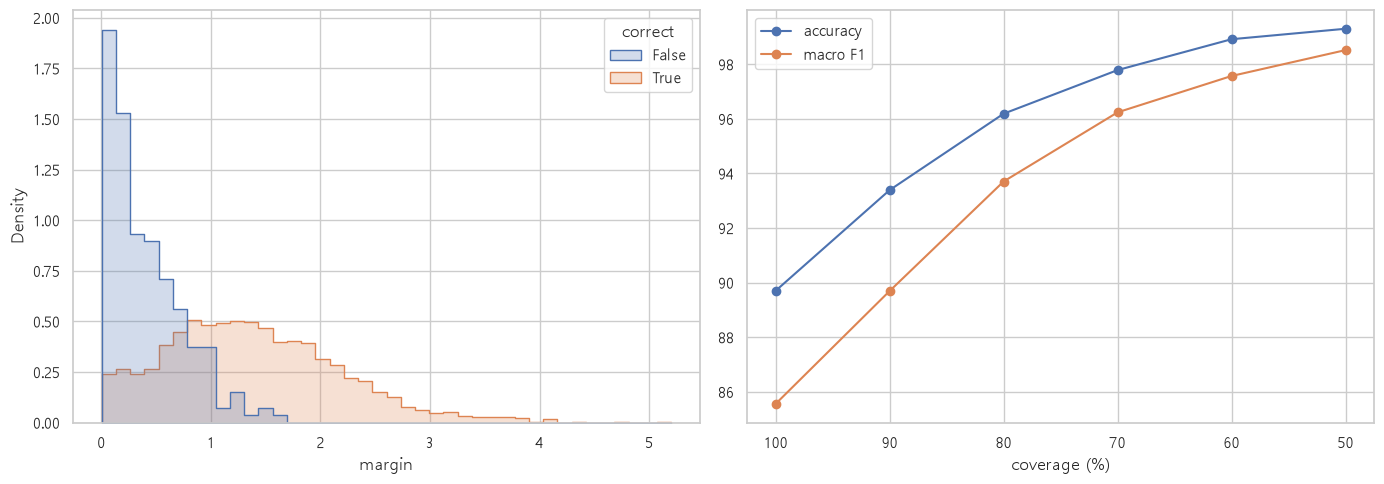

In [28]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.histplot(data=test_eval,x='margin',hue='correct',bins=40,element='step',stat='density',common_norm=False,ax=axes[0])
axes[1].plot(coverage_df.coverage*100,coverage_df.accuracy*100,marker='o',label='accuracy')
axes[1].plot(coverage_df.coverage*100,coverage_df.macro_f1*100,marker='o',label='macro F1')
axes[1].invert_xaxis(); axes[1].legend(); axes[1].set_xlabel('coverage (%)')
plt.tight_layout(); plt.show()

## 15. 긍정·부정 이진 분류

In [29]:
train_bin=train[train.label!=5].copy()
test_bin=test[test.label!=5].copy()
y_bin=train_bin.label.isin([1,2]).astype(int)
y_bin_test=test_bin.label.isin([1,2]).astype(int)
print('train:',y_bin.value_counts().rename(index={0:'negative',1:'positive'}).to_dict())
print('test:',y_bin_test.value_counts().rename(index={0:'negative',1:'positive'}).to_dict())

train: {'negative': 9784, 'positive': 7517}
test: {'negative': 1080, 'positive': 854}


In [30]:
binary_model=make_hybrid_model()
binary_model.fit(train_bin.clean_text,y_bin)
binary_pred=binary_model.predict(test_bin.clean_text)
binary_decision=binary_model.decision_function(test_bin.clean_text)
binary_metrics={'accuracy':accuracy_score(y_bin_test,binary_pred),
                'macro_f1':f1_score(y_bin_test,binary_pred,average='macro'),
                'roc_auc':roc_auc_score(y_bin_test,binary_decision)}
binary_metrics

{'accuracy': 0.9782833505687694,
 'macro_f1': 0.9780242494026388,
 'roc_auc': 0.9970086304102698}

              precision    recall  f1-score   support

    negative     0.9878    0.9731    0.9804      1080
    positive     0.9667    0.9848    0.9756       854

    accuracy                         0.9783      1934
   macro avg     0.9772    0.9790    0.9780      1934
weighted avg     0.9785    0.9783    0.9783      1934



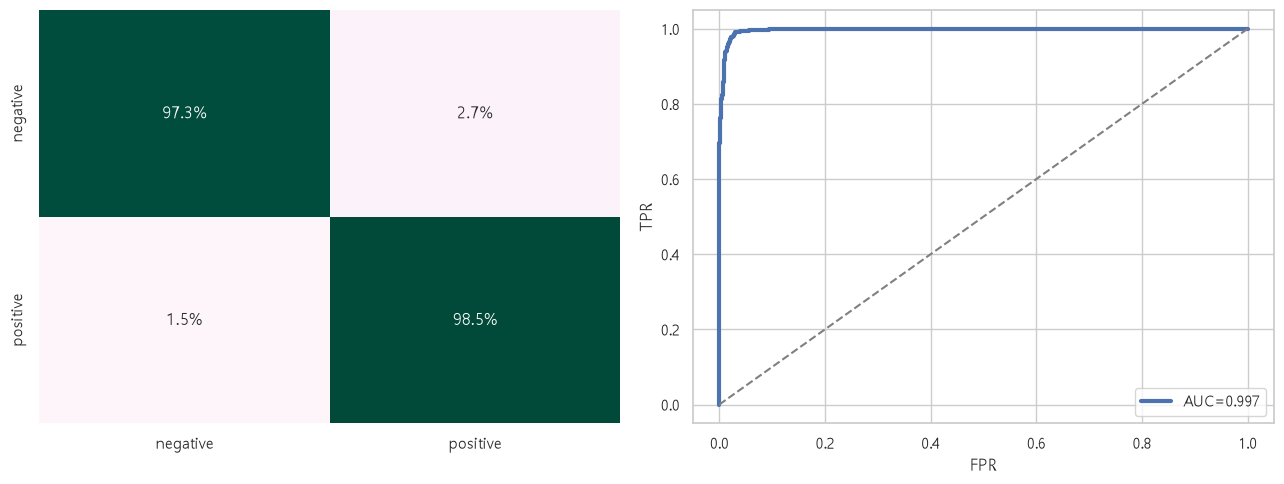

In [31]:
print(classification_report(y_bin_test,binary_pred,target_names=['negative','positive'],digits=4))
bcm=confusion_matrix(y_bin_test,binary_pred,normalize='true')
fpr,tpr,_=roc_curve(y_bin_test,binary_decision)
fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.heatmap(bcm,annot=True,fmt='.1%',cmap='PuBuGn',vmin=0,vmax=1,
            xticklabels=['negative','positive'],yticklabels=['negative','positive'],cbar=False,ax=axes[0])
axes[1].plot(fpr,tpr,lw=3,label=f'AUC={binary_metrics["roc_auc"]:.3f}')
axes[1].plot([0,1],[0,1],'--',color='gray'); axes[1].legend(loc='lower right')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
plt.tight_layout(); plt.show()

,6-class,binary
accuracy,0.89700,0.978283
macro_f1,0.85557,0.978024


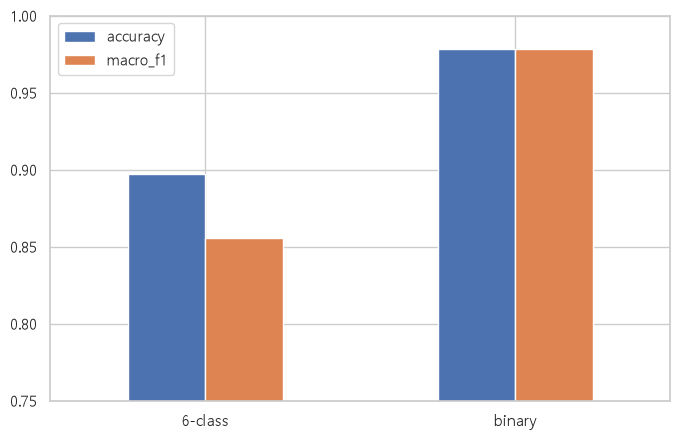

In [32]:
comparison=pd.DataFrame({
    '6-class':[multi_metrics['accuracy'],multi_metrics['macro_f1']],
    'binary':[binary_metrics['accuracy'],binary_metrics['macro_f1']]},
    index=['accuracy','macro_f1'])
display(comparison)
comparison.T.plot(kind='bar',ylim=(.75,1),rot=0,figsize=(8,5)); plt.show()

## 16. 결과 파일 저장

In [33]:
output_dir=Path('/content') if Path('/content').exists() else Path('work/mission14/notebook_runtime')
output_dir.mkdir(parents=True,exist_ok=True)
multi_out=test[['text','label']].copy()
multi_out['true_emotion']=multi_out.label.map(LABELS)
multi_out['pred_label']=pred
multi_out['pred_emotion']=multi_out.pred_label.map(LABELS)
multi_out['decision_margin']=test_eval.margin.values
multi_out.to_csv(output_dir/'mission14_multiclass_predictions.csv',index=False,encoding='utf-8-sig')

binary_out=test_bin[['text','label']].copy()
binary_out['true_polarity']=np.where(y_bin_test.values==1,'positive','negative')
binary_out['pred_polarity']=np.where(binary_pred==1,'positive','negative')
binary_out['decision_score']=binary_decision
binary_out.to_csv(output_dir/'mission14_binary_predictions.csv',index=False,encoding='utf-8-sig')

keywords.to_csv(output_dir/'mission14_wordcloud_keywords.csv',index=False,encoding='utf-8-sig')
joblib.dump(final_model,output_dir/'mission14_multiclass_model.joblib')
joblib.dump(binary_model,output_dir/'mission14_binary_model.joblib')
print('saved to:',output_dir.resolve())

saved to: C:\Users\lucy5\Documents\Codex\2026-09-14\13-1-eda-2-k-means\work\mission14\notebook_runtime


## 17. 결론과 한계

- 워드클라우드는 품사·표제어·공통어 제거·감정 특이도 가중이 해석력을 높였습니다.
- 분류에는 최소 정제와 word+character TF-IDF 결합이 가장 좋았습니다.
- 낮은 margin 예측은 사람 검토 또는 중립 처리하는 것이 안전합니다.
- 혼합 감정, 풍자, 플랫폼 변화에는 한계가 있으며 신규 도메인에서 재검증해야 합니다.
- 감정 예측을 고객 제재나 고위험 의사결정의 단독 근거로 사용하면 안 됩니다.